# **Modulo 6. Proyecto 2.**

Found 1869 images belonging to 15 classes.
Found 75 images belonging to 15 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 38s 602ms/step - accuracy: 0.1805 - loss: 2.5816 - val_accuracy: 0.6133 - val_loss: 1.2733
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 37s 623ms/step - accuracy: 0.5494 - loss: 1.4153 - val_accuracy: 0.7467 - val_loss: 0.9003
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 36s 603ms/step - accuracy: 0.7057 - loss: 0.9609 - val_accuracy: 0.7467 - val_loss: 0.7395
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 36s 615ms/step - accuracy: 0.7614 - loss: 0.7406 - val_accuracy: 0.8267 - val_loss: 0.5412
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 40s 602ms/step - accuracy: 0.8189 - loss: 0.5554 - val_accuracy: 0.8000 - val_loss: 0.5543
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 37s 622ms/step - accuracy: 0.8836 - loss: 0.3843 - val_accuracy: 0.8667 - val_loss: 0.4917
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 40s 599ms/step - accuracy: 0.8825 - loss: 0.3675 - val_accuracy: 0.8000 - val_loss: 0.5451
Epoch 8/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 36s 605ms/step - accuracy: 0.9302 - loss: 0.2335 - val_accu

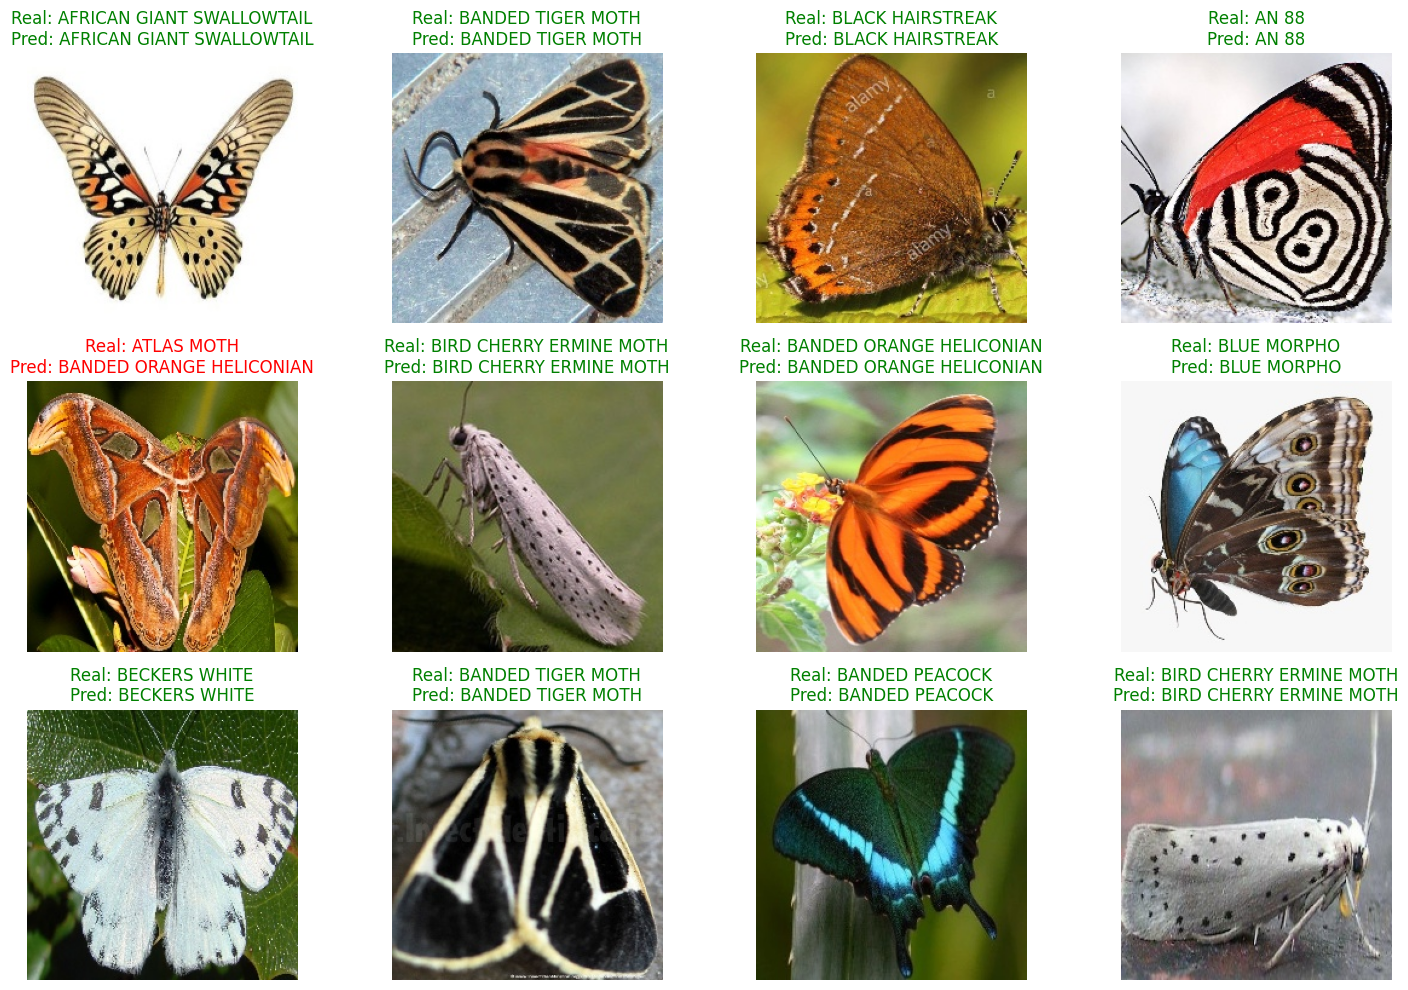

In [6]:
import os
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


train_dir = "/content/drive/MyDrive/mariposas/train"
test_dir = "/content/drive/MyDrive/mariposas/test"

image_size = (100, 100)
batch_size = 32

# Generadores de imágenes
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

num_classes = train_generator.num_classes

#CNN
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(*image_size, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Entrenar
history = model.fit(train_generator, epochs=10, validation_data=test_generator)

# Evaluar
test_generator.reset()
preds = model.predict(test_generator)
y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

print("Métricas globales Sin Filtro:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

#Ejemplos de predicciones
import random
def mostrar_predicciones(test_generator, y_pred, y_true, class_labels, n=12):
    indices = random.sample(range(len(y_pred)), n)
    plt.figure(figsize=(15, 10))
    for i, idx in enumerate(indices):
        img_path = test_generator.filepaths[idx]
        img = plt.imread(img_path)
        pred = class_labels[y_pred[idx]]
        real = class_labels[y_true[idx]]
        color = 'green' if pred == real else 'red'

        plt.subplot(3, 4, i+1)
        plt.imshow(img)
        plt.title(f"Real: {real}\nPred: {pred}", color=color)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

mostrar_predicciones(test_generator, y_pred, y_true, class_labels)




Found 1869 images belonging to 15 classes.
Found 75 images belonging to 15 classes.
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


59/59 ━━━━━━━━━━━━━━━━━━━━ 32s 504ms/step - accuracy: 0.0652 - loss: 3.1814 - val_accuracy: 0.1867 - val_loss: 2.5698
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 30s 507ms/step - accuracy: 0.2355 - loss: 2.4226 - val_accuracy: 0.3867 - val_loss: 2.0011
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 30s 513ms/step - accuracy: 0.4999 - loss: 1.6555 - val_accuracy: 0.4000 - val_loss: 1.8080
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 30s 510ms/step - accuracy: 0.6494 - loss: 1.1066 - val_accuracy: 0.4533 - val_loss: 1.7707
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 30s 509ms/step - accuracy: 0.7920 - loss: 0.6585 - val_accuracy: 0.4133 - val_loss: 1.8500
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 41s 513ms/step - accuracy: 0.8230 - loss: 0.5321 - val_accuracy: 0.4133 - val_loss: 2.1698
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 30s 515ms/step - accuracy: 0.8501 - loss: 0.4530 - val_accuracy: 0.4267 - val_loss: 2.0535
Epoch 8/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 30s 514ms/step - accuracy: 0.8953 - loss: 0.3166 - val_accuracy: 0.453

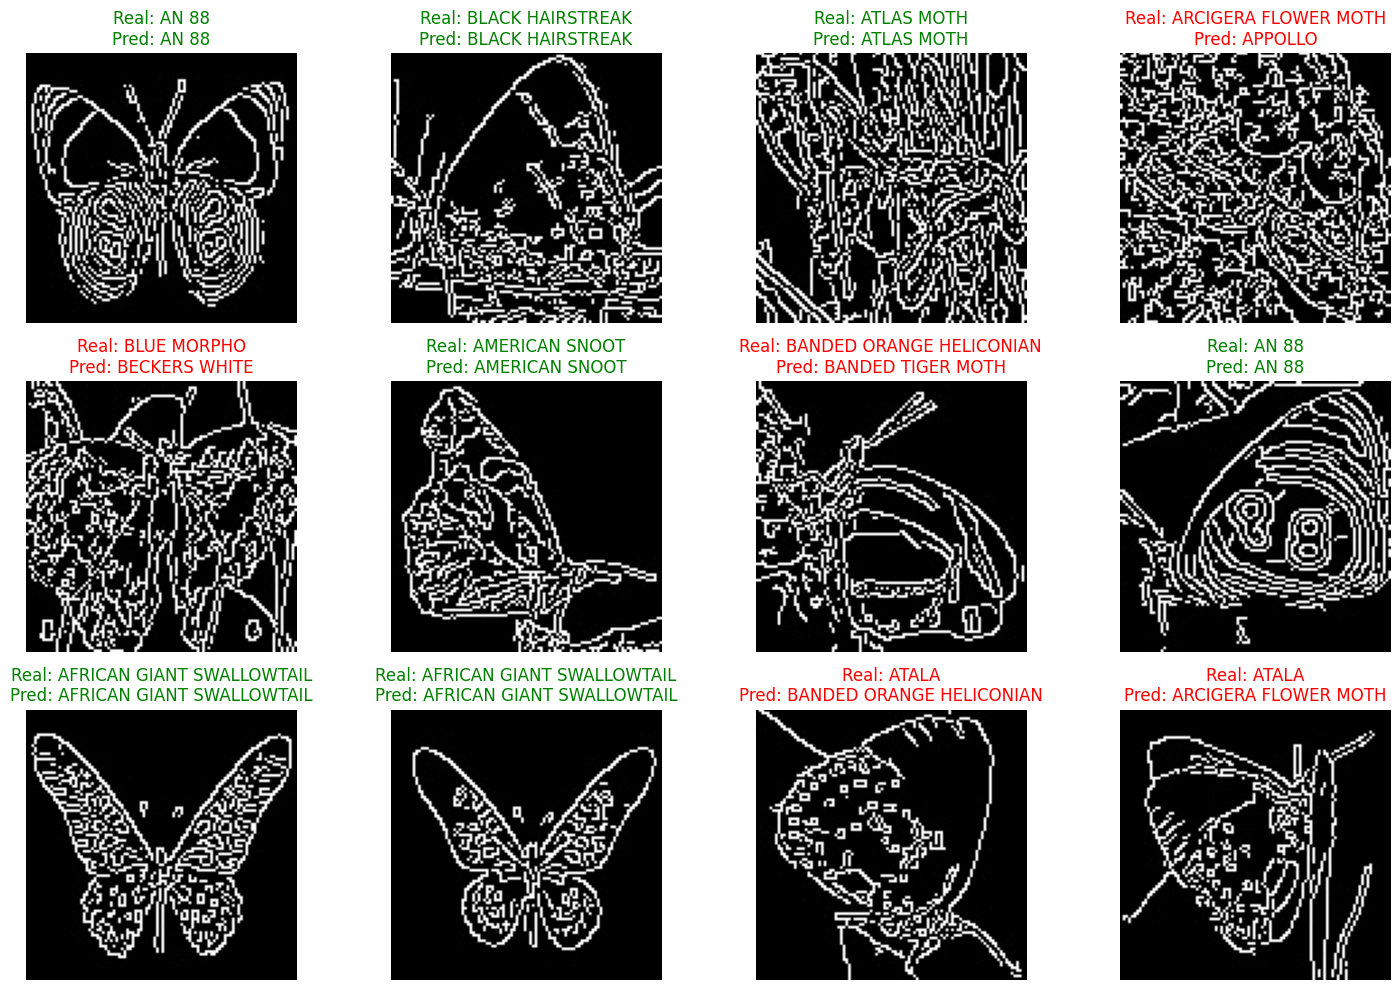

In [7]:
import cv2
import shutil
from tqdm import tqdm

def filtro_s(origen, destino, filtro='canny'):
    if os.path.exists(destino):
        shutil.rmtree(destino)
    os.makedirs(destino)

    for clase in os.listdir(origen):
        origen_clase = os.path.join(origen, clase)
        destino_clase = os.path.join(destino, clase)
        os.makedirs(destino_clase)

        for img_file in os.listdir(origen_clase):
            img_path = os.path.join(origen_clase, img_file)
            img = cv2.imread(img_path)
            img = cv2.resize(img, image_size)

            if filtro == 'canny':
                img = cv2.Canny(img, 100, 200)
            elif filtro == 'sobel':
                sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=5)
                sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=5)
                img = cv2.magnitude(sobelx, sobely)
                img = cv2.convertScaleAbs(img)
            else:
                raise ValueError("Filtro no soportado")

            if len(img.shape) == 2:
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

            cv2.imwrite(os.path.join(destino_clase, img_file), img)


filtro = 'canny'
train_dir_f = "/content/filtered/train"
test_dir_f = "/content/filtered/test"

filtro_s(train_dir, train_dir_f, filtro)
filtro_s(test_dir, test_dir_f, filtro)


train_gen_f = ImageDataGenerator(rescale=1./255)
test_gen_f = ImageDataGenerator(rescale=1./255)

train_f = train_gen_f.flow_from_directory(
    train_dir_f,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_f = test_gen_f.flow_from_directory(
    test_dir_f,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


model_f = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(*image_size, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model_f.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_f = model_f.fit(train_f, epochs=10, validation_data=test_f)

test_f.reset()
preds_f = model_f.predict(test_f)
y_pred_f = np.argmax(preds_f, axis=1)
y_true_f = test_f.classes

accuracy_f = accuracy_score(y_true_f, y_pred_f)
precision_f = precision_score(y_true_f, y_pred_f, average='macro', zero_division=0)
recall_f = recall_score(y_true_f, y_pred_f, average='macro', zero_division=0)
f1_f = f1_score(y_true_f, y_pred_f, average='macro', zero_division=0)

print(f"\nMétricas globales CON filtro {filtro.upper()}:")
print(f"Accuracy : {accuracy_f:.4f}")
print(f"Precision: {precision_f:.4f}")
print(f"Recall   : {recall_f:.4f}")
print(f"F1-score : {f1_f:.4f}")

mostrar_predicciones(test_f, y_pred_f, y_true_f, class_labels)


Found 1869 images belonging to 15 classes.
Found 75 images belonging to 15 classes.
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


59/59 ━━━━━━━━━━━━━━━━━━━━ 33s 514ms/step - accuracy: 0.0805 - loss: 3.3311 - val_accuracy: 0.1733 - val_loss: 2.4813
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 41s 517ms/step - accuracy: 0.2059 - loss: 2.4521 - val_accuracy: 0.2667 - val_loss: 2.2231
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 41s 522ms/step - accuracy: 0.2975 - loss: 2.2318 - val_accuracy: 0.3733 - val_loss: 2.0687
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 31s 521ms/step - accuracy: 0.3724 - loss: 1.9594 - val_accuracy: 0.3733 - val_loss: 1.9342
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 30s 508ms/step - accuracy: 0.4647 - loss: 1.6949 - val_accuracy: 0.4267 - val_loss: 1.8841
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 30s 512ms/step - accuracy: 0.5780 - loss: 1.4607 - val_accuracy: 0.4267 - val_loss: 1.9422
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 32s 534ms/step - accuracy: 0.5950 - loss: 1.2660 - val_accuracy: 0.4267 - val_loss: 1.8189
Epoch 8/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 31s 529ms/step - accuracy: 0.6978 - loss: 0.9708 - val_accuracy: 0.413

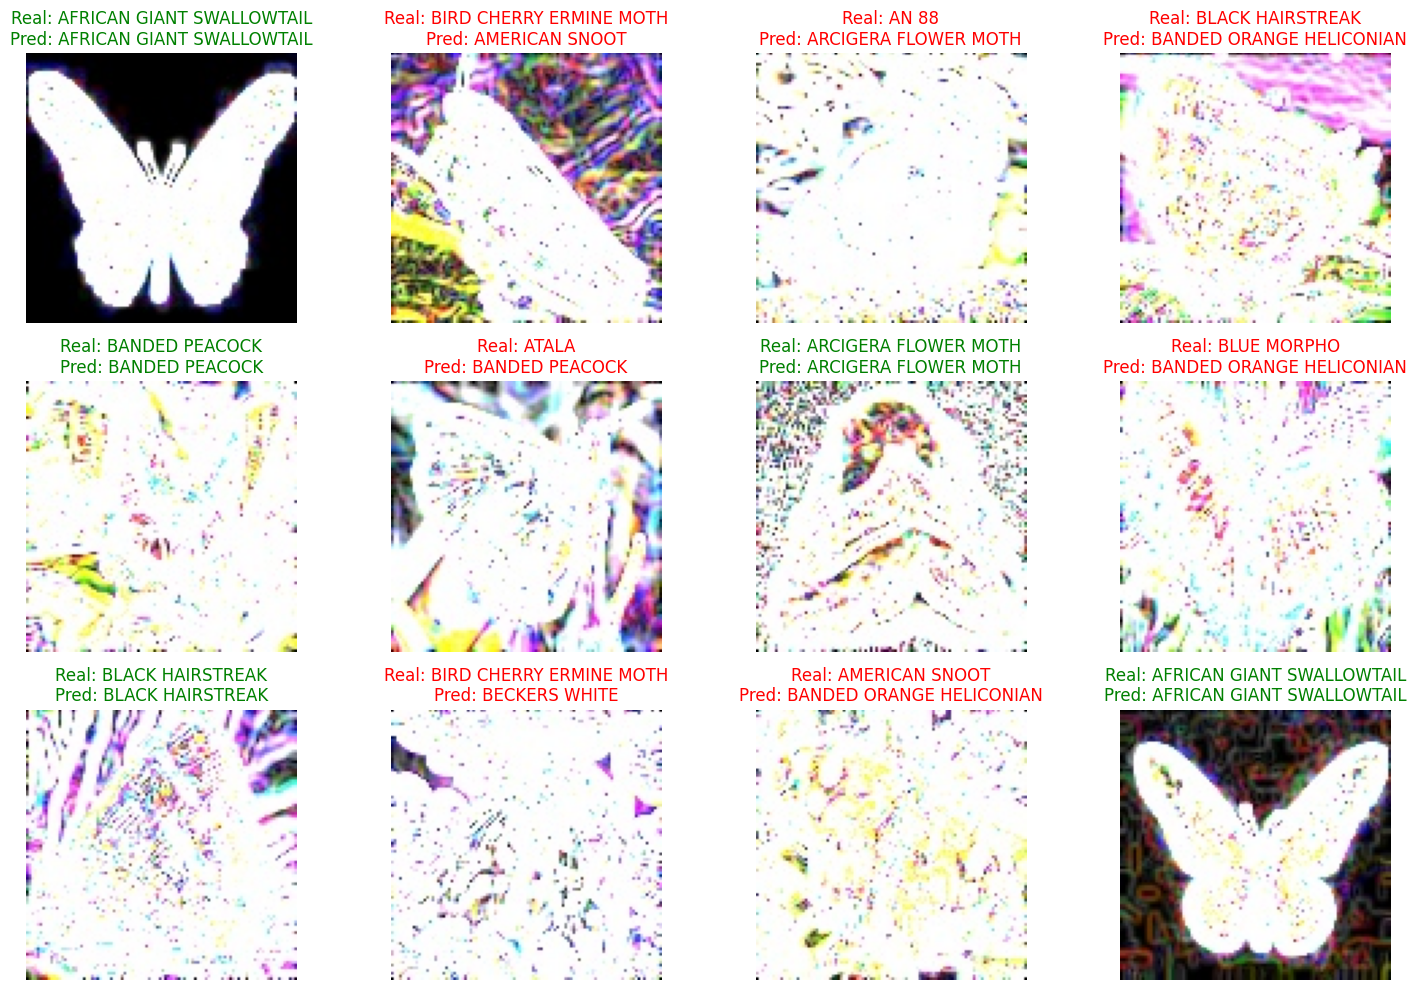

In [5]:
def filtro_s(origen, destino, filtro='canny'):
    if os.path.exists(destino):
        shutil.rmtree(destino)
    os.makedirs(destino)

    for clase in os.listdir(origen):
        origen_clase = os.path.join(origen, clase)
        destino_clase = os.path.join(destino, clase)
        os.makedirs(destino_clase)

        for img_file in os.listdir(origen_clase):
            img_path = os.path.join(origen_clase, img_file)
            img = cv2.imread(img_path)
            img = cv2.resize(img, image_size)

            if filtro == 'canny':
                img = cv2.Canny(img, 100, 200)
            elif filtro == 'sobel':
                sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=5)
                sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=5)
                img = cv2.magnitude(sobelx, sobely)
                img = cv2.convertScaleAbs(img)
            else:
                raise ValueError("Filtro no soportado")

            if len(img.shape) == 2:
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

            cv2.imwrite(os.path.join(destino_clase, img_file), img)


filtro = 'sobel'
train_dir_f = "/content/filtereds/train"
test_dir_f = "/content/filtereds/test"

filtro_s(train_dir, train_dir_f, filtro)
filtro_s(test_dir, test_dir_f, filtro)


train_gen_f = ImageDataGenerator(rescale=1./255)
test_gen_f = ImageDataGenerator(rescale=1./255)

train_f = train_gen_f.flow_from_directory(
    train_dir_f,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_f = test_gen_f.flow_from_directory(
    test_dir_f,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


model_f = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(*image_size, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model_f.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Entrenar
history_f = model_f.fit(train_f, epochs=10, validation_data=test_f)


test_f.reset()
preds_f = model_f.predict(test_f)
y_pred_f = np.argmax(preds_f, axis=1)
y_true_f = test_f.classes

accuracy_f = accuracy_score(y_true_f, y_pred_f)
precision_f = precision_score(y_true_f, y_pred_f, average='macro', zero_division=0)
recall_f = recall_score(y_true_f, y_pred_f, average='macro', zero_division=0)
f1_f = f1_score(y_true_f, y_pred_f, average='macro', zero_division=0)

print(f"\nMétricas globales CON filtro {filtro.upper()}:")
print(f"Accuracy : {accuracy_f:.4f}")
print(f"Precision: {precision_f:.4f}")
print(f"Recall   : {recall_f:.4f}")
print(f"F1-score : {f1_f:.4f}")


mostrar_predicciones(test_f, y_pred_f, y_true_f, class_labels)


# **Comentarios**

En este proyectó se pudo observar el impacto de dos filtros: Canny y Sobel sobre el desempeño de una CNN para la clasificación de imágenes de mariposas según su especie.

Comenzamos utilizando las imágenes sin ningún filtro. Después se utilizó Canny, un filtro que detecta bordes en una imagen y finalmente se utilizó Sobel.

A continuación se presentan las métricas obtenidas en cada caso:

| Filtro       | Accuracy | Precision | Recall | F1-score |
|--------------|----------|-----------|--------|----------|
| Sin filtro   | 0.8400   | 0.8721    | 0.8400 | 0.8409   |
| Canny        | 0.4533   | 0.5174    | 0.4533 | 0.4361   |
| Sobel        | 0.3867   | 0.4259    | 0.3867 | 0.3898   |

El mejor desempeño se consiguio al utilizar las imágenes sin ningún filtro, podemos notar que con el filtro Canny se redujo notablemente el rendimiento del modelo lo mismo que con Sobel que fue el que más redujo el rendimiento del modelo.

Estos resultados son esperados debido a la naturaleza de las imágenes. Aunque los filtros Canny y Sobel que detectan bordes pueden ser útiles en ciertos contextos, en éste en particular no lo son ya que, las características como los colores, la textura y los patrones -que estos filtros eliminan- resultan cruciales para la clasificación de las mariposas.

